**Dépôt GitHub : https://github.com/PHR-IDS/Python-Activite-Physique-Groupe

**Membres :** Paul-Henri Roueche / PENA Alexis / FERREIRA Guillaume


# ENMO par epoch — HAH913E-Physical-activity-00



Objectif de ce TP : 
Rappel consigne : à partir des données brutes d'un accéléromètre au poignet (fichier `0_z.csv`, colonnes t/x/y/z), calculer un indicateur d'intensité du mouvement appelé **ENMO** (Euclidean Norm Minus One), puis regarder son évolution en le moyennant sur des fenêtres de temps de 10s, 30s et 60s.

L'idée de l'ENMO : au repos, le capteur mesure quand même ~1g à cause de la gravité, peu importe comment le poignet est orienté. Donc si on calcule juste la norme du vecteur (x,y,z), on ne voit jamais 0 même immobile. L'ENMO enlève ce 1g :

ENMO = max( sqrt(x² + y² + z²) − 1 , 0 )

Le `max(..., 0)` sert à éviter d'avoir des valeurs négatives à cause du bruit du capteur (des mesures où la norme est légèrement < 1g), ce qui n'aurait pas de sens pour une "intensité de mouvement".

## 1. Chargement des données



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def load_accelerometer_data(path):
    """Charge le fichier CSV (colonnes t, x, y, z en g)."""
    return pd.read_csv(path, comment="#")

df = load_accelerometer_data("0_z.csv")
df.head()


,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


**Vérification :
Avant d'avancer , je regarde que le fichier s'est bien chargé comme attendu : 
 colonnes Check
pas de valeur manquante check 
 un pas de temps régulier (le capteur échantillonne normalement à fréquence fixe) check
  ->t doit avancer d'un pas constant d'une ligne à l'autre


In [3]:
print("colonnes :", list(df.columns))
print("nombre de lignes :", len(df))
print("valeurs manquantes par colonne :\n", df.isna().sum())

dt = df["t"].diff().dropna()
print("\npas de temps : min =", dt.min(), "max =", dt.max(), "(devrait être quasi constant)")
print("fréquence d'échantillonnage estimée :", round(1 / dt.median(), 1), "Hz")

assert df.isna().sum().sum() == 0, "il y a des valeurs manquantes, à traiter avant de continuer"
assert dt.max() - dt.min() < 0.01, "le pas de temps n'est pas régulier, à vérifier"
print("\n-> OK, les données sont propres et régulièrement échantillonnées.")


colonnes : ['t', 'x', 'y', 'z']
nombre de lignes : 21000
valeurs manquantes par colonne :
 t    0
x    0
y    0
z    0
dtype: int64

pas de temps : min = 0.01999999999998181 max = 0.020000000000038654 (devrait être quasi constant)
fréquence d'échantillonnage estimée : 50.0 Hz

-> OK, les données sont propres et régulièrement échantillonnées.


**Alternative :charger directement  le fichier avec le module `csv` natif de Python. 

In [4]:
import csv

def load_accelerometer_data_csv(path):
    """Même chargement que load_accelerometer_data, avec le module csv natif."""
    rows = []
    with open(path) as f:
        next(f)  # on saute la ligne de commentaire "# accelerometer data in g"
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})
    return rows

rows_csv = load_accelerometer_data_csv("0_z.csv")
print("nombre de lignes :", len(rows_csv))
rows_csv[:3]


nombre de lignes : 21000


[{'t': 0.0, 'x': -0.0938, 'y': -0.0156, 'z': 0.9531},
 {'t': 0.02, 'x': -0.0938, 'y': -0.0156, 'z': 0.9531},
 {'t': 0.04, 'x': -0.0938, 'y': -0.0156, 'z': 0.9531}]

## 2. Calcul de l'ENMO

fonction séparée ,respect de la consigne (utiliser des fonctions). 


In [5]:
def compute_enmo(df):
    """ENMO = max(norme du vecteur (x,y,z) - 1, 0)."""
    norm = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
    return (norm - 1).clip(lower=0)

df["enmo"] = compute_enmo(df)
df[["t", "x", "y", "z", "enmo"]].head()


,t,x,y,z,enmo
0,0.00,-0.0938,-0.0156,0.9531,0.0
1,0.02,-0.0938,-0.0156,0.9531,0.0
2,0.04,-0.0938,-0.0156,0.9531,0.0
3,0.06,-0.0938,-0.0156,0.9531,0.0
4,0.08,-0.0938,-0.0156,0.9531,0.0


Vérification 
verification : ENMO ne doit jamais être négative 
Code tourne mais valeur peuvent être fausse 
vérification ligne 



In [6]:
assert (df["enmo"] >= 0).all(), "il y a des valeurs d'ENMO négatives, la fonction a un problème"

i = 100
x, y, z = df.loc[i, ["x", "y", "z"]]
enmo_manuel = max((x**2 + y**2 + z**2) ** 0.5 - 1, 0)
print(f"ligne {i} : ENMO calculée = {df.loc[i, 'enmo']:.6f}, ENMO recalculée à la main = {enmo_manuel:.6f}")

assert abs(df.loc[i, "enmo"] - enmo_manuel) < 1e-9, "l'ENMO calculée à la main ne correspond pas"
print("-> OK, la fonction calcule bien ce qui est attendu.")


ligne 100 : ENMO calculée = 0.000000, ENMO recalculée à la main = 0.000000
-> OK, la fonction calcule bien ce qui est attendu.


## 3. Moyenner par epoch

Les données brutes sont à 50 Hz 
  découper le temps en tranches fixes ("epochs") et de faire la moyenne de l'ENMO dans chaque tranche.

--> (`t // epoch_s`), +  `groupby` + `mean` fait le calcul par groupe.

(groupby > boucle for sur en terme de temps 



In [7]:
def aggregate_enmo_by_epoch(t, enmo, epoch_s):
    """Moyenne l'ENMO par epoch de epoch_s secondes.
    Retourne les temps de début d'epoch et la moyenne correspondante.
    """
    epoch_index = (t // epoch_s).astype(int)
    enmo_mean = enmo.groupby(epoch_index).mean()
    return pd.DataFrame({
        "epoch_start": enmo_mean.index * epoch_s,
        "enmo_mean": enmo_mean.values,
    })

agg_10 = aggregate_enmo_by_epoch(df["t"], df["enmo"], 10)
agg_10.head()


,epoch_start,enmo_mean
0,0,0.00004
1,10,0.00000
2,20,0.00000
3,30,0.00000
4,40,0.00000


**Vérification :** 
 1/ nombre d'epochs obtenu (durée totale de l'enregistrement divisée par la durée d'epoch, arrondie),  
 2/  la moyenne globale de l'ENMO agrégée reste proche de la moyenne calculée directement sur les données brutes sinon prolbème 


In [8]:
duree_totale = df["t"].max() - df["t"].min()
nb_epochs_attendu = int(duree_totale // 10) + 1
print(f"durée totale : {duree_totale:.1f}s -> {nb_epochs_attendu} epochs de 10s attendues, {len(agg_10)} obtenues")
assert len(agg_10) == nb_epochs_attendu, "le nombre d'epochs ne correspond pas à ce qui est attendu"

moyenne_brute = df["enmo"].mean()
moyenne_agregee = agg_10["enmo_mean"].mean()
print(f"ENMO moyen (données brutes) : {moyenne_brute:.5f}")
print(f"ENMO moyen (moyenne des epochs de 10s) : {moyenne_agregee:.5f}")
assert abs(moyenne_brute - moyenne_agregee) < 0.01, "les deux moyennes divergent trop, il y a peut-être un souci dans le regroupement"
print("-> OK, l'agrégation par epoch est cohérente avec les données brutes.")


durée totale : 420.0s -> 42 epochs de 10s attendues, 42 obtenues
ENMO moyen (données brutes) : 0.05130
ENMO moyen (moyenne des epochs de 10s) : 0.05130
-> OK, l'agrégation par epoch est cohérente avec les données brutes.


## 4. Les graphiques



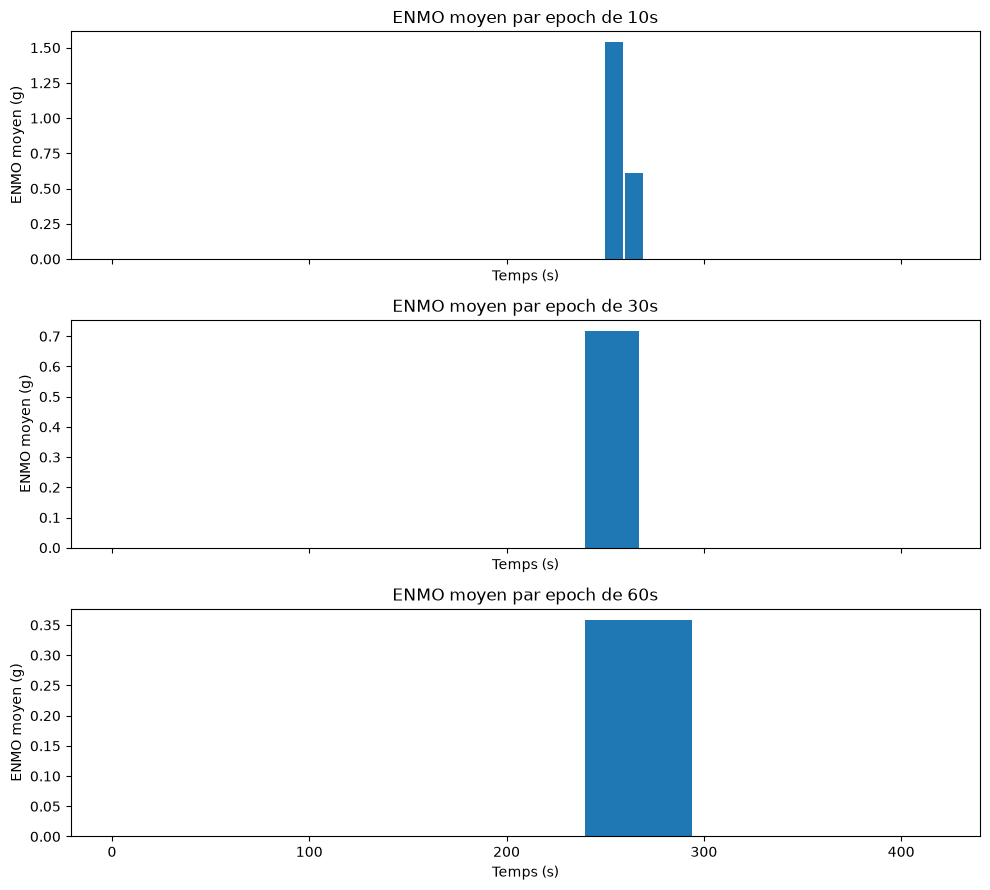

In [9]:
def plot_enmo_by_epoch(agg_df, epoch_s, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    ax.bar(agg_df["epoch_start"], agg_df["enmo_mean"], width=epoch_s * 0.9, align="edge")
    ax.set_xlabel("Temps (s)")
    ax.set_ylabel("ENMO moyen (g)")
    ax.set_title(f"ENMO moyen par epoch de {epoch_s}s")
    return ax

epochs = [10, 30, 60]
aggregations = {}
fig, axes = plt.subplots(len(epochs), 1, figsize=(10, 9), sharex=True)

for ax, epoch_s in zip(axes, epochs):
    agg = aggregate_enmo_by_epoch(df["t"], df["enmo"], epoch_s)
    aggregations[epoch_s] = agg
    plot_enmo_by_epoch(agg, epoch_s, ax=ax)

plt.tight_layout()
plt.show()


## Ce que j'en retiens

Ce TP m’a permis de comprendre comment passer des données brutes d’un accéléromètre à une mesure plus facile à interpréter avec l’ENMO. L’ENMO permet d’enlever l’effet de la gravité afin de mieux représenter les mouvements du poignet.

J’ai aussi compris que le choix de la durée des epochs est important. Avec des epochs de 10 secondes, on observe mieux les changements rapides d’activité. Avec des epochs de 30 secondes puis 60 secondes, les valeurs sont davantage moyennées et le graphique devient plus lissé.

On obtient donc plus ou moins de détails sur l’activité physique selon la durée des epochs choisie.

## Utilisation de Copilot

Prompts utilisés :
- Écris une fonction Python qui charge un fichier CSV contenant les colonnes t, x, y et z avec pandas.
- Crée une fonction Python qui calcule l’ENMO à partir de x, y et z avec la formule max(sqrt(x²+y²+z²)-1,0).
- Crée une fonction qui regroupe les valeurs d’ENMO par epochs de 10, 30 et 60 secondes et calcule la moyenne pour chaque epoch.
- Crée une fonction avec matplotlib permettant de tracer l’ENMO moyen en fonction du temps pour plusieurs tailles d’epoch.



Après vérification :
Nous avons ajouté des contrôles sur les valeurs manquantes, la régularité du pas de temps, l’absence de valeurs d’ENMO négatives et la cohérence des epochs obtenus.

# Conclusion

Le traitement réalisé permet de calculer l’ENMO à partir des données brutes de l’accéléromètre et de visualiser son évolution avec des epochs de 10 s, 30 s et 60 s. Lorsque la durée de l’epoch augmente, les valeurs sont davantage moyennées, ce qui lisse les variations rapides de l’activité.